<a href="https://colab.research.google.com/github/lojainstar/SADAIABB/blob/main/NANO_GPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/karpathy/nanoGPT.git
%cd nanoGPT

!rm -rf data/shakespeare_char
!rm -rf data/shakespeare

Cloning into 'nanoGPT'...
remote: Enumerating objects: 689, done.
remote: Total 689 (delta 0), reused 0 (delta 0), pack-reused 689 (from 1)
Receiving objects: 100% (689/689), 975.25 KiB | 16.81 MiB/s, done.
Resolving deltas: 100% (382/382), done.
/content/nanoGPT


In [2]:

!mkdir -p data/athar



In [3]:
%%writefile prepare.py

from datasets import load_dataset
import tiktoken
import sentencepiece as spm
import numpy as np
import os
import pickle
#البيانات والحجم
dataset = load_dataset("mohamed-khalil/ATHAR", split="train")
dataset = dataset.select(range(40000))

texts = [x['arabic'] for x in dataset if x['arabic']]
full_text = "\n".join(texts)

os.makedirs("data/athar", exist_ok=True)

with open("data/athar/text.txt", "w") as f:
    f.write(full_text)

#استخدمت SentencePiece مع خوارزمية BPE لبناء tokenizer خاص باللغة العربية


spm.SentencePieceTrainer.train(
    input="data/athar/text.txt",
    model_prefix="tokenizer/athar_sp",
    vocab_size=8000,
    model_type="bpe",
    character_coverage=0.9995
)

print("TOKENIZER TRAINED")

sp = spm.SentencePieceProcessor()
sp.load("tokenizer/athar_sp.model")

tokens = sp.encode(full_text, out_type=int)
tokens = np.array(tokens, dtype=np.uint16)

split = int(0.9 * len(tokens))
train_ids = tokens[:split]
val_ids = tokens[split:]

train_ids.tofile("data/athar/train.bin")
val_ids.tofile("data/athar/val.bin")

meta = {"vocab_size": enc.n_vocab}
with open("data/athar/meta.pkl", "wb") as f:
    pickle.dump(meta, f)



Writing prepare.py


In [4]:
!python prepare.py

README.md: 11.7kB [00:00, 7.54MB/s]
data/train-00000-of-00001.parquet: 100% 14.5M/14.5M [00:01<00:00, 8.76MB/s]
data/test-00000-of-00001.parquet: 100% 251k/251k [00:00<00:00, 1.13MB/s]
Generating train split: 100% 65043/65043 [00:00<00:00, 304995.70 examples/s]
Generating test split: 100% 1000/1000 [00:00<00:00, 185827.12 examples/s]
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: data/athar/text.txt
  input_format: 
  model_prefix: tokenizer/athar_sp
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  require

In [ ]:
split = int(0.9 * len(tokens))
train_ids = tokens[:split]
val_ids = tokens[split:]

In [ ]:
train_ids.tofile("data/athar/train.bin")
val_ids.tofile("data/athar/val.bin")

In [ ]:
meta = {"vocab_size": enc.n_vocab}
with open("data/athar/meta.pkl", "wb") as f:
    pickle.dump(meta, f)

In [6]:
!python data/athar/prepare.py

python3: can't open file '/content/nanoGPT/data/athar/prepare.py': [Errno 2] No such file or directory


In [7]:
%%writefile config/train_athar.py

# Dataset name
dataset = 'athar'

out_dir = 'out-athar'

# model size
n_layer = 4
n_head = 4
n_embd = 128

#training
batch_size = 32
block_size = 128

learning_rate = 3e-4
init_from = 'resume'
out_dir = 'out-athar'
max_iters = 5000


#evaluation
eval_interval = 200
eval_iters = 100

# logging
log_interval = 10

Writing config/train_athar.py


In [ ]:
!python train.py config/train_athar.py

Overriding config with config/train_athar.py:

# Dataset name
dataset = 'athar'

out_dir = 'out-athar'

# model size
n_layer = 4
n_head = 4
n_embd = 128

#training
batch_size = 32
block_size = 128

learning_rate = 3e-4
init_from = 'resume'
out_dir = 'out-athar'
max_iters = 5000


#evaluation
eval_interval = 200
eval_iters = 100

# logging
log_interval = 10

tokens per iteration will be: 163,840
found vocab_size = 8000 (inside data/athar/meta.pkl)
Resuming training from out-athar
Traceback (most recent call last):
  File "/content/nanoGPT/nanoGPT/train.py", line 162, in <module>
    checkpoint = torch.load(ckpt_path, map_location=device)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 1500, in load
    with _open_file_like(f, "rb") as opened_file:
         ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 768, in _open_file_like
    return _open_

In [ ]:
!python sample.py \
--out_dir=out-athar \
--start="امير المؤمنين" \
--num_samples=1 \
--max_new_tokens=200

Overriding: out_dir = out-athar
Overriding: start = امير المؤمنين
Overriding: num_samples = 1
Overriding: max_new_tokens = 200
number of parameters: 1.81M
Loading tokenizer...
امير المؤمنين. فقال له بل أنت هذا يا أمير المؤمنين. قال لا يا أمير المؤمنين، إني لأمتها عليك بكل ما أكلت ملّمت، وما كان من عمدان له أديناه، وما زلت في ديننا، وأحظما الله على أن المال، وأنها عفو، وأينظرها من أمواذ هذه الأدب، ولآخر يا أبلك، فقال إنّ الضّاج متجّل، وأنّك تعت، فعوانبه، وأدبوا مزيد فأوقف، ثم قال له أيّها الحسن، إنّ لك هذا صحيح، واستخفّظت الناس من المؤاكلة وكالما، وإن كنت لا ذنب له، فأصبحت في رأس الأدب، وآخرها، فإنها تدور، وتزيّف المعاصي ومن كلّما، ومن أحسن حال وقال أبو الهيجاء على أهل خراسان، واستدأت إلى أن تقلّد عليّ من الكلام، فقال له ما أنت من جهّك؟ يا أمير المؤمنين. وقال له يا


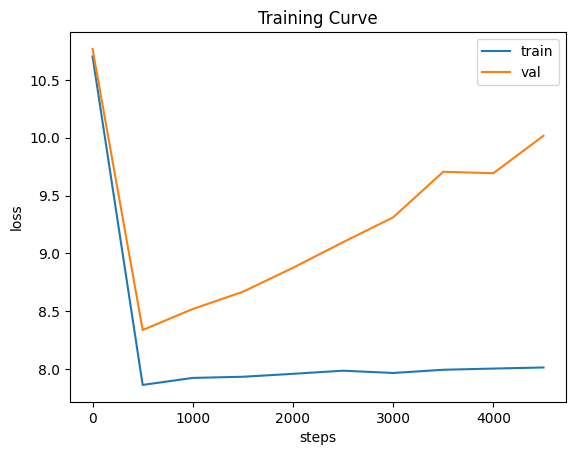

In [ ]:
import matplotlib.pyplot as plt
import pickle

data = pickle.load(open("losses.pkl", "rb"))

plt.plot(data["steps"], data["train"], label="train")
plt.plot(data["steps"], data["val"], label="val")

plt.xlabel("steps")
plt.ylabel("loss")
plt.legend()
plt.title("Training Curve")
plt.show()

#تم طباعة نسبة الخساره بالكامل ولكن  واجهت مشكلة checkpoint المودل تعلم لكن حدث فرط تعلم قليلا

In [8]:
!zip -r nanoGPT_project.zip /content/nanoGPT

  adding: content/nanoGPT/ (stored 0%)
  adding: content/nanoGPT/data/ (stored 0%)
  adding: content/nanoGPT/data/athar/ (stored 0%)
  adding: content/nanoGPT/data/athar/text.txt (deflated 75%)
  adding: content/nanoGPT/data/openwebtext/ (stored 0%)
  adding: content/nanoGPT/data/openwebtext/readme.md (deflated 31%)
  adding: content/nanoGPT/data/openwebtext/prepare.py (deflated 54%)
  adding: content/nanoGPT/.ipynb_checkpoints/ (stored 0%)
  adding: content/nanoGPT/transformer_sizing.ipynb (deflated 71%)
  adding: content/nanoGPT/.gitattributes (deflated 31%)
  adding: content/nanoGPT/model.py (deflated 67%)
  adding: content/nanoGPT/.git/ (stored 0%)
  adding: content/nanoGPT/.git/info/ (stored 0%)
  adding: content/nanoGPT/.git/info/exclude (deflated 28%)
  adding: content/nanoGPT/.git/hooks/ (stored 0%)
  adding: content/nanoGPT/.git/hooks/fsmonitor-watchman.sample (deflated 62%)
  adding: content/nanoGPT/.git/hooks/pre-applypatch.sample (deflated 38%)
  adding: content/nanoGPT/.gi

In [9]:
from google.colab import files
files.download("nanoGPT_project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>